<a href="https://colab.research.google.com/github/ReiLamaj1/ClassWork_UPT_CV_2026/blob/main/module2_supervised_segmentation_practices_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Supervised Segmentation**
This is a method where a model learns to segment an image using labeled training data.This means that the algorithm learns from images where each pixel has a correct label,so instead of guessing groups,it learns from examples.



LDA stands for linear discriminant analysis and this method is used for classification and sometimes on segmentation tasks.This method finds a projection that best separates different classes,and tries to make points from the same class close together and points from different classes far apart.This method is supervised so it needs input data and labels.LDA tries to maximize distance between class means and minimize variation inside each class.Now below we are going to tell step by step how it works,first we have to compute class mean,this means that for each class we have to calculate average feature vector,after that we have to measure spread,within-class scatter and between class scatter.After that we have to finds a projection that maximize those two scatters.Data is projected into a new space where classes are best separated.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


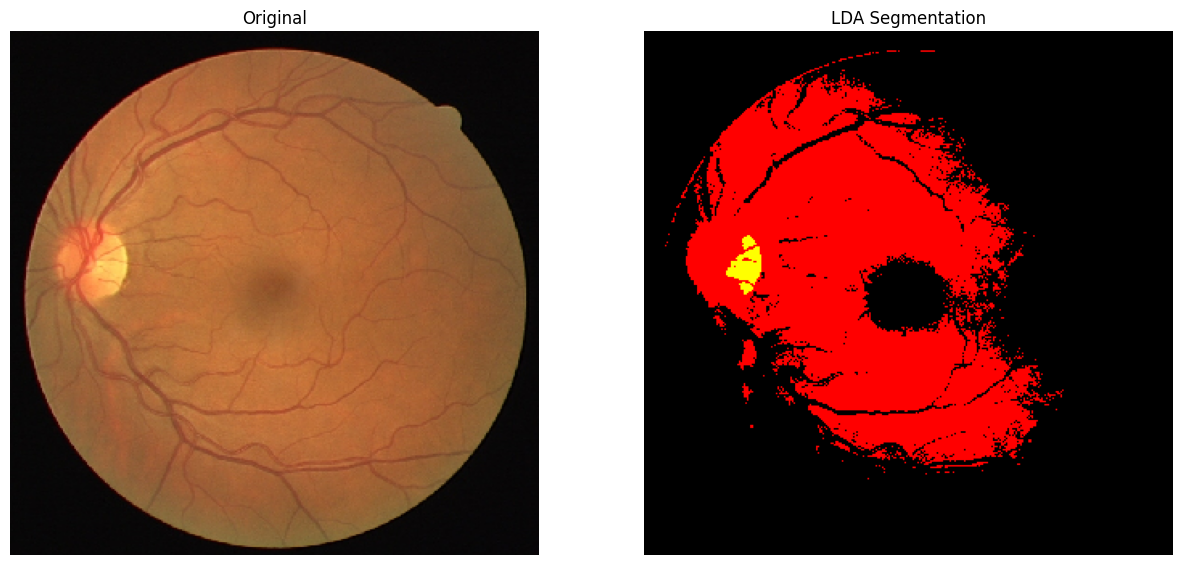

In [29]:
import skimage as sk
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
import os
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/'
I_train = sk.io.imread(os.path.join(path, 'photo.png'))
I_train_GT = sk.io.imread(os.path.join(path, 'photo_mask.png'))
if I_train_GT.shape != I_train.shape:
    I_train_GT = sk.transform.resize(I_train_GT, I_train.shape, preserve_range=True)
v_I_train = I_train.reshape(-1, 1).astype(np.uint8)
v_train_GT = I_train_GT.reshape(-1, 1).astype(np.uint8)
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(v_I_train, v_train_GT.ravel())
v_lda = lda_model.predict(v_I_train)
I_lda = v_lda.reshape(I_train.shape)
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(I_train, cmap='gray')
ax[0].set_title("Original")
ax[0].axis('off')
ax[1].imshow(I_lda, cmap='gray')
ax[1].set_title("LDA Segmentation")
ax[1].axis('off')

plt.show()

QDA is a supervised classifier used for classification and image segmentation this method learns how to separate classes curved boundaries(it is non-linear).QDA works in this form first it split data into classes and learn statistics for each class this means that it computes mean covariance matrix for every class.Each class follows a bell-shaped distribution but with different shapes so background may be spread differently and object may be more concentraed.After that QDA compares probabilities for each class and chooses the higher one.

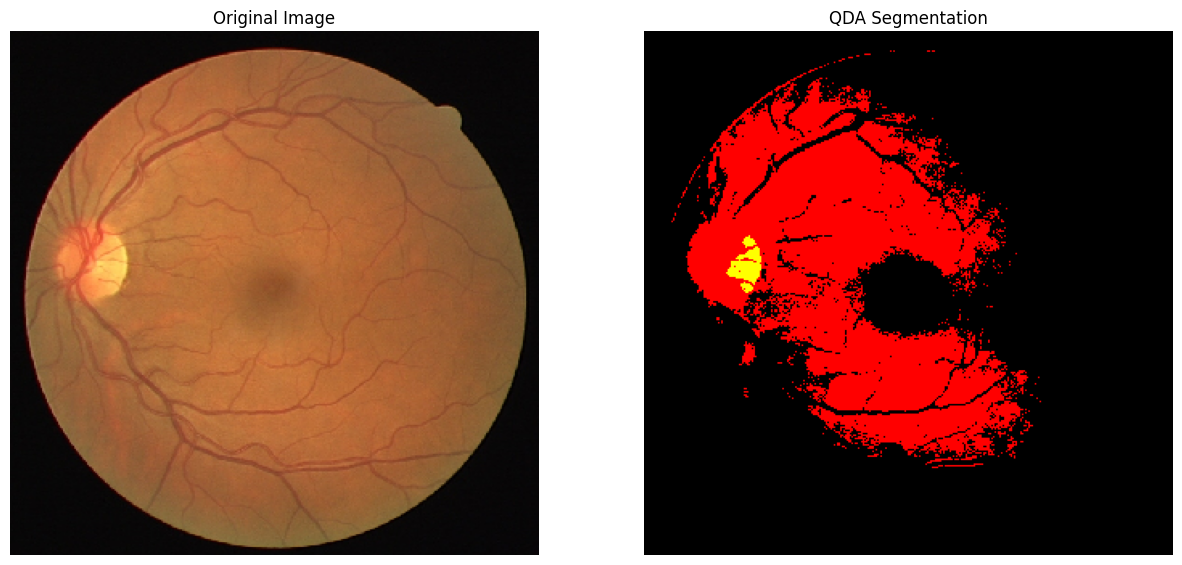

In [30]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import numpy as np
import matplotlib.pyplot as plt
v_I_train = I_train.reshape(-1, 1).astype(np.uint8)
v_train_GT = I_train_GT.reshape(-1, 1).astype(np.uint8)
qda_model = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_model.fit(v_I_train, v_train_GT.ravel())
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(I_train, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(I_qda, cmap='gray')
ax[1].set_title('QDA Segmentation')
ax[1].axis('off')
plt.show()

Gaussian Naive Bayes is a simple probabilistic method based on Bayes theorem.Itis used for classification and for image segmentation.The core idea is that what is the probability that a pixel belongs to class 0 or class 1 then it picks the class with the highest probability.We should mention that in this method all features are independent of each other this is a strong assumption but it works well.This method works in this form,first for each class we have to find mean and variance after that for a pixel value we have to use gaussian formula and this gices how likely x belongs to that class.After finding probbaility for each class next is to use Bayes theorem which combines probabilities,in the end we have to choose the class with the higher probability.

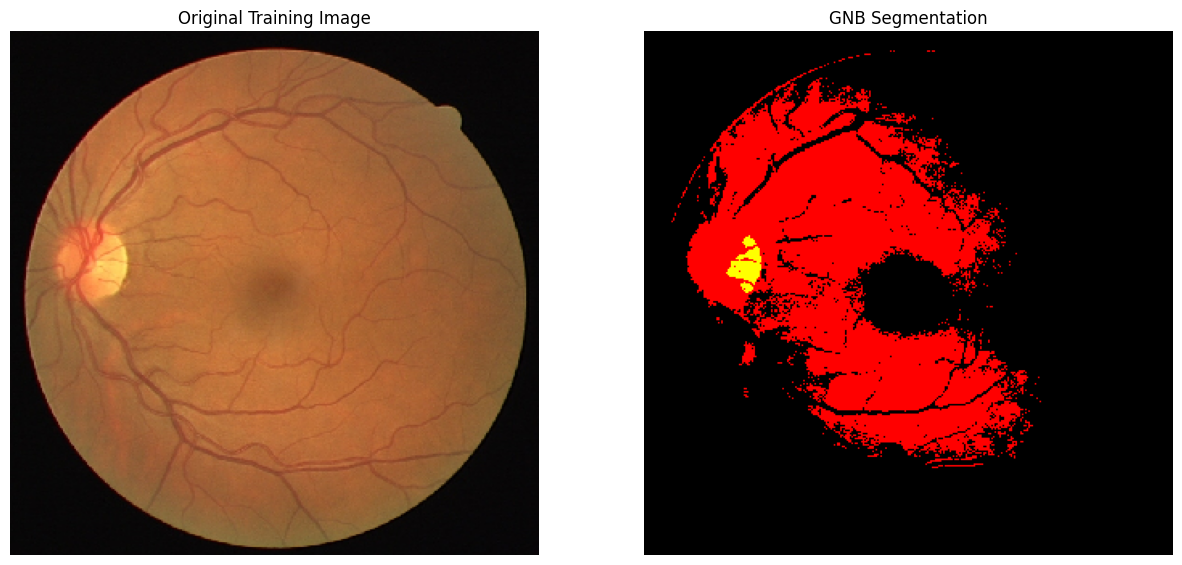

In [31]:
from sklearn.naive_bayes import GaussianNB
import numpy as np
import matplotlib.pyplot as plt
v_I_train = I_train.reshape(-1, 1).astype(np.uint8)
v_train_GT = I_train_GT.reshape(-1, 1).astype(np.uint8)
gnb_model = GaussianNB()
gnb_model.fit(v_I_train, v_train_GT.ravel())
v_gnb = gnb_model.predict(v_I_train)
I_gnb = v_gnb.reshape(I_train.shape).astype(np.uint8)
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(I_train, cmap='gray')
ax[0].set_title('Original Training Image')
ax[0].axis('off')
ax[1].imshow(I_gnb, cmap='gray')
ax[1].set_title('GNB Segmentation')
ax[1].axis('off')

plt.show()